## 1. Preparación de Datos

In [42]:
# =============================================================================
# 1 — Librerías y Configuración Global
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
from scipy.stats.mstats import winsorize

import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---------- Estilo académico ----------
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_style("whitegrid")

# ---------- Constantes ----------
WINDOWS        = [12, 24, 36]       # Ventanas móviles (meses)
N_QUANTILES    = 5                   # Quintiles
MIN_MONTHS     = 24                  # Meses mínimos de historia por acción
MIN_STOCKS     = 8                   # Mínimo de acciones por mes
NW_LAGS        = 6                   # Rezagos Newey-West
START_DATE     = '2000-01-01'
END_DATE       = '2023-12-31'

# ---------- Rutas de CSVs ----------
PATH_FACTORS = 'data/[per]_[all_factors]_[monthly]_[vw_cap].csv'
PATH_THEMES  = 'data/[per]_[all_themes]_[monthly]_[vw_cap].csv'
PATH_MKT     = 'data/[per]_[mkt]_[monthly]_[vw_cap].csv'

print("Librerías cargadas. Configuración lista.")

Librerías cargadas. Configuración lista.


In [43]:
# =============================================================================
# 2 — Elección de acciones peruanas (BVL + ADR)
# =============================================================================
# Tickers de la Bolsa de Valores de Lima (.LM) y ADRs peruanos listados en EE.UU.
# Agrupados por sector para facilitar la exclusión de financieros.

TICKERS_UNIVERSE = {
    # ---- Minería ----
    'BVN':        'Compañía de Minas Buenaventura',
    'SCCO':       'Southern Copper Corp',
    'CVERDEC1.LM':'Sociedad Minera Cerro Verde',
    'VOLCABC1.LM':'Volcan Compañía Minera',
    'MINSURI1.LM':'Compañía Minera Milpo (Minsur)',
    'ATACOBC1.LM':'Compañía Minera Atacocha',
    'MORROC1.LM': 'Minera Morococha (hoy Nexa)',
    'SIDERC1.LM': 'Empresa Siderúrgica del Perú – SIDERPERU',
    'PODERC1.LM': 'Sociedad Minera El Brocal (Poderosa)',
    'BROCALC1.LM':'Sociedad Minera El Brocal',
    'NEXAPEI1.LM':'Nexa Resources Peru',
    'TREVALI.LM':  'Trevali Mining',
    'RAURAI1.LM':  'Compañía Minera Raura',

    # ---- Energía / Utilities ----
    'ENGIEC1.LM': 'Engie Energía Perú',
    'ENERSUC1.LM':'Enel Generación Piura (Enersur)',
    'EABORAC1.LM':'Electro Austral (EABORA)',
    'EDABORC1.LM':'Electro Dunas',
    'LUSURC1.LM': 'Luz del Sur',
    'EDELNOC1.LM':'Enel Distribución Perú (Edelnor)',
    'ENDISPC1.LM':'Enel Distribución Perú',
    'ENGEPEC1.LM':'Engie Energía Perú (duplicado check)',
    'COMDNPC1.LM':'HidrandCEM (CMD)',
    'HIDRA2C1.LM':'HidrandinaEM Hidra',

    # ---- Industriales / Construcción ----
    'CPACASC1.LM':'Cementos Pacasmayo',
    'UNACEMC1.LM':'Unión Andina de Cementos (UNACEM)',
    'CORAREC1.LM':'Corporación Aceros Arequipa (CAASA)',
    'ETERNIC1.LM':'Compañía Industrial El Pacífico (Eternit)',
    'FERREYC1.LM':'Ferreycorp',
    'INABORC1.LM':'Industrial INABOR',

    # ---- Consumo / Alimentos / Agroindustria ----
    'ALICORC1.LM':'Alicorp',
    'BACKUBC1.LM':'Unión de Cervecerías Peruanas Backus y Johnston',
    'CASAGRC1.LM':'Casa Grande (Grupo Gloria)',
    'CARTAVC1.LM':'Cartavio (Grupo Gloria)',
    'LAABORC1.LM':'Laive',
    'GLORIAC1.LM': 'Gloria',
    'LINDLEC1.LM': 'Corporación Lindley (Arca Continental)',
    'TV':          'Grupo Televisa (ADR proxy)',
    'AUSTRAC1.LM': 'Austral Group',

    # ---- Telecomunicaciones ----
    'TEF':         'Telefónica (proxy — principal telco en Perú)',

    # ---- Diversificados / Holdings ----
    'GRAMONC1.LM':'Graña y Montero (hoy Aenza)',
    'AABORAC1.LM':'AABORA',
    'INRETC1.LM':  'InRetail Peru Corp',

    # ---- Inmobiliario ----
    'INVITAC1.LM': 'Inversiones Centenario',
}

print(f"Número total de Tickers:  {len(TICKERS_UNIVERSE)} tickers")

Número total de Tickers:  43 tickers


In [44]:
# =============================================================================
# Cell 3 — Descarga de precios mensuales desde Yahoo Finance
# =============================================================================
tickers_list = list(TICKERS_UNIVERSE.keys())
print(f"Descargando datos de {len(tickers_list)} tickers...")

# Descarga batch — intervalo mensual
raw = yf.download(
    tickers_list,
    start=START_DATE,
    end=END_DATE,
    interval='1mo',
    group_by='ticker',
    auto_adjust=True,
    progress=True,
    threads=True,
)

# ---------- Construir panel largo (date, ticker, ret, volume, close) ----------
records = []
failed_tickers = []

for tk in tickers_list:
    try:
        if len(tickers_list) == 1:
            df_tk = raw.copy()
        else:
            df_tk = raw[tk].copy()
        df_tk = df_tk.dropna(subset=['Close'])
        if len(df_tk) < 6:
            failed_tickers.append(tk)
            continue
        df_tk = df_tk.reset_index()
        df_tk.columns = [c[0] if isinstance(c, tuple) else c for c in df_tk.columns]
        df_tk = df_tk.rename(columns={'Date': 'date'})
        df_tk['ticker'] = tk
        df_tk['ret'] = df_tk['Close'].pct_change()
        df_tk['volume_usd'] = df_tk['Close'] * df_tk['Volume']
        records.append(df_tk[['date', 'ticker', 'Close', 'Volume', 'volume_usd', 'ret']].iloc[1:])  # drop first NaN
    except Exception as e:
        failed_tickers.append(tk)

returns_panel = pd.concat(records, ignore_index=True)
returns_panel['date'] = pd.to_datetime(returns_panel['date'])
# Normalizar a fin de mes
returns_panel['date'] = returns_panel['date'] + pd.offsets.MonthEnd(0)

print(f"\nPanel de retornos: {len(returns_panel):,} obs, {returns_panel['ticker'].nunique()} tickers")
print(f"  Rango: {returns_panel['date'].min().date()} → {returns_panel['date'].max().date()}")
if failed_tickers:
    print(f"  Tickers fallidos ({len(failed_tickers)}): {failed_tickers}")

Descargando datos de 43 tickers...


[*********************100%***********************]  43 of 43 completed

24 Failed downloads:
['NEXAPEI1.LM', 'BACKUBC1.LM', 'BROCALC1.LM', 'INVITAC1.LM', 'CORAREC1.LM', 'GLORIAC1.LM', 'MORROC1.LM', 'CARTAVC1.LM', 'COMDNPC1.LM', 'AABORAC1.LM', 'CASAGRC1.LM', 'HIDRA2C1.LM', 'EDABORC1.LM', 'INABORC1.LM', 'ENERSUC1.LM', 'EABORAC1.LM', 'RAURAI1.LM', 'LINDLEC1.LM', 'EDELNOC1.LM', 'ETERNIC1.LM', 'TREVALI.LM', 'PODERC1.LM', 'LAABORC1.LM']: YFTzMissingError('possibly delisted; no timezone found')
['ENDISPC1.LM']: YFPricesMissingError('possibly delisted; no price data found  (1mo 2000-01-01 -> 2023-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 946702800, endDate = 1703998800")')



Panel de retornos: 3,956 obs, 19 tickers
  Rango: 2000-02-29 → 2023-12-31
  Tickers fallidos (24): ['MORROC1.LM', 'PODERC1.LM', 'BROCALC1.LM', 'NEXAPEI1.LM', 'TREVALI.LM', 'RAURAI1.LM', 'ENERSUC1.LM', 'EABORAC1.LM', 'EDABORC1.LM', 'EDELNOC1.LM', 'ENDISPC1.LM', 'COMDNPC1.LM', 'HIDRA2C1.LM', 'CORAREC1.LM', 'ETERNIC1.LM', 'INABORC1.LM', 'BACKUBC1.LM', 'CASAGRC1.LM', 'CARTAVC1.LM', 'LAABORC1.LM', 'GLORIAC1.LM', 'LINDLEC1.LM', 'AABORAC1.LM', 'INVITAC1.LM']


In [45]:
# =============================================================================
# 4 — Descarga de datos fundamentales (balance, income, cashflow)
# =============================================================================
def fetch_fundamentals(ticker_str):
    """
    Descarga balance_sheet, financials (income) y cashflow de yfinance.
    Devuelve un DataFrame anual con columnas clave, o None si falla.
    """
    try:
        tk_obj = yf.Ticker(ticker_str)
        bs  = tk_obj.balance_sheet          # anual
        inc = tk_obj.financials             # anual (income statement)
        cf  = tk_obj.cashflow               # anual

        # Transponer: columnas => filas (cada columna es una fecha)
        frames = {}
        if bs is not None and not bs.empty:
            frames['bs'] = bs.T
        if inc is not None and not inc.empty:
            frames['inc'] = inc.T
        if cf is not None and not cf.empty:
            frames['cf'] = cf.T

        if not frames:
            return None

        # Merge todas las fuentes por fecha (índice)
        merged = pd.DataFrame(index=frames[list(frames.keys())[0]].index)
        for key, df_ in frames.items():
            merged = merged.join(df_, how='outer', rsuffix=f'_{key}')

        merged.index = pd.to_datetime(merged.index)
        merged = merged.sort_index()

        # Extraer campos clave (nombres comunes en yfinance)
        def safe_col(df, candidates):
            for c in candidates:
                if c in df.columns:
                    return df[c]
            return pd.Series(np.nan, index=df.index)

        out = pd.DataFrame(index=merged.index)
        out['total_assets']   = safe_col(merged, ['Total Assets', 'TotalAssets'])
        out['book_equity']    = safe_col(merged, ['Total Stockholder Equity',
                                                   'Stockholders Equity',
                                                   'Total Equity Gross Minority Interest',
                                                   'StockholdersEquity'])
        out['gross_profit']   = safe_col(merged, ['Gross Profit', 'GrossProfit'])
        out['net_income']     = safe_col(merged, ['Net Income', 'NetIncome',
                                                   'Net Income From Continuing Operations'])
        out['revenue']        = safe_col(merged, ['Total Revenue', 'TotalRevenue',
                                                   'Operating Revenue'])
        out['total_debt']     = safe_col(merged, ['Total Debt', 'TotalDebt',
                                                   'Long Term Debt', 'LongTermDebt'])
        out['capex']          = safe_col(merged, ['Capital Expenditure',
                                                   'Capital Expenditures',
                                                   'CapitalExpenditure'])
        out['operating_income'] = safe_col(merged, ['Operating Income',
                                                     'OperatingIncome', 'EBIT'])
        out['cash']           = safe_col(merged, ['Cash And Cash Equivalents',
                                                   'Cash', 'CashAndCashEquivalents'])
        out['ticker'] = ticker_str
        return out.reset_index().rename(columns={'index': 'date'})
    except Exception:
        return None

# Descargar fundamentales para todo el universo
print("Descargando fundamentales (balance, income, cashflow)...")
fund_list = []
fund_failed = []
for i, tk in enumerate(tickers_list):
    df_fund = fetch_fundamentals(tk)
    if df_fund is not None and len(df_fund) > 0:
        fund_list.append(df_fund)
    else:
        fund_failed.append(tk)
    if (i + 1) % 10 == 0:
        print(f"  ... {i+1}/{len(tickers_list)} procesados")

if fund_list:
    fundamentals_annual = pd.concat(fund_list, ignore_index=True)
    fundamentals_annual['date'] = pd.to_datetime(fundamentals_annual['date'])
    print(f"\n Fundamentales anuales: {len(fundamentals_annual)} obs, "
          f"{fundamentals_annual['ticker'].nunique()} tickers")
else:
    fundamentals_annual = pd.DataFrame()
    print("\n No se obtuvieron fundamentales de ningún ticker.")

if fund_failed:
    print(f"  Sin fundamentales ({len(fund_failed)}): {fund_failed[:15]}{'...' if len(fund_failed)>15 else ''}")

Descargando fundamentales (balance, income, cashflow)...
  ... 10/43 procesados
  ... 20/43 procesados
  ... 30/43 procesados
  ... 40/43 procesados

 Fundamentales anuales: 71 obs, 18 tickers
  Sin fundamentales (25): ['MORROC1.LM', 'SIDERC1.LM', 'PODERC1.LM', 'BROCALC1.LM', 'NEXAPEI1.LM', 'TREVALI.LM', 'RAURAI1.LM', 'ENERSUC1.LM', 'EABORAC1.LM', 'EDABORC1.LM', 'EDELNOC1.LM', 'COMDNPC1.LM', 'HIDRA2C1.LM', 'CORAREC1.LM', 'ETERNIC1.LM']...


In [46]:
# =============================================================================
# 5 — Construcción de características a nivel de acción-mes
# =============================================================================
# 5a. Forward-fill fundamentales anuales a frecuencia mensual por ticker
def expand_fundamentals_to_monthly(fund_df, returns_df):
    """
    Expande datos anuales a mensuales usando forward-fill.
    Cada dato anual se imputa hacia adelante hasta el siguiente reporte.
    CORREGCIÓN: Aplica rezago de 4 meses a fundamentales para evitar look-ahead bias.
    """
    if fund_df.empty:
        return pd.DataFrame()

    all_months = returns_df[['date']].drop_duplicates().sort_values('date')
    tickers_fund = fund_df['ticker'].unique()
    expanded = []

    for tk in tickers_fund:
        df_tk = fund_df[fund_df['ticker'] == tk].copy()
        # CORRECCIÓN 1: Aplicar rezago de 4 meses para simular publicación realista de fundamentales
        df_tk['date'] = df_tk['date'] + pd.DateOffset(months=4) + pd.offsets.MonthEnd(0)
        df_tk = df_tk.drop_duplicates(subset='date', keep='last')
        # Reindex a todos los meses y ffill
        months_tk = all_months.copy()
        months_tk['ticker'] = tk
        merged = months_tk.merge(df_tk.drop(columns='ticker'), on='date', how='left')
        merged = merged.sort_values('date')
        cols_fund = [c for c in merged.columns if c not in ['date', 'ticker']]
        merged[cols_fund] = merged[cols_fund].ffill()
        expanded.append(merged)

    return pd.concat(expanded, ignore_index=True)

fund_monthly = expand_fundamentals_to_monthly(fundamentals_annual, returns_panel)
print(f"Fundamentales expandidos a mensual (con rezago de 4 meses): {len(fund_monthly):,} obs")

# 5b. Merge retornos + fundamentales
panel = returns_panel.merge(fund_monthly, on=['date', 'ticker'], how='left')

# 5c. Obtener market_equity desde yfinance .info (shares_outstanding × price)
# Usamos Close * un estimado de shares a partir de info cuando esté disponible
shares_dict = {}
for tk in tickers_list:
    try:
        info = yf.Ticker(tk).info
        shares = info.get('sharesOutstanding', None)
        if shares and shares > 0:
            shares_dict[tk] = shares
    except Exception:
        pass

# Aproximar market_equity = Close * shares_outstanding (constante — mejor disponible)
panel['shares'] = panel['ticker'].map(shares_dict)
panel['market_equity'] = panel['Close'] * panel['shares']

# Para tickers sin shares, usar Close como proxy de tamaño relativo
if panel['market_equity'].isna().all():
    panel['market_equity'] = panel['Close']
else:
    med_mktcap = panel['market_equity'].median()
    panel['market_equity'] = panel['market_equity'].fillna(med_mktcap)

# 5d. Calcular características basadas en precios
panel = panel.sort_values(['ticker', 'date']).reset_index(drop=True)
grp = panel.groupby('ticker')

# Momentum
panel['ret_1_0']  = grp['ret'].shift(0)                              # Reversal (1-mes)
panel['ret_6_1']  = grp['Close'].pct_change(6).shift(1)              # Mom 6m (skip 1)
panel['ret_12_1'] = grp['Close'].pct_change(12).shift(1)             # Mom 12m (skip 1)

# Volatilidad (std de retornos últimos 12 meses)
panel['ivol_12m'] = grp['ret'].transform(lambda x: x.rolling(12, min_periods=6).std())

# Volumen promedio (liquidez, últimos 6 meses)
panel['dolvol_6m'] = grp['volume_usd'].transform(lambda x: x.rolling(6, min_periods=3).mean())
panel['dolvol_6m_log'] = np.log1p(panel['dolvol_6m'])

# Tamaño (log market equity)
panel['size'] = np.log1p(panel['market_equity'])

# 5e. Calcular características basadas en fundamentales
panel['be_me'] = panel['book_equity'] / panel['market_equity']
panel['at_me'] = panel['total_assets'] / panel['market_equity']
panel['ni_me'] = panel['net_income'] / panel['market_equity']
panel['gp_at'] = panel['gross_profit'] / panel['total_assets']
panel['ope_be'] = panel['operating_income'] / panel['book_equity']
panel['debt_at'] = panel['total_debt'] / panel['total_assets']

# Crecimiento de activos (YoY) — requiere 12-month lag
panel['at_gr1'] = grp['total_assets'].pct_change(12)
panel['sale_gr1'] = grp['revenue'].pct_change(12)

# Accruals simplificados: (Δassets - Δcash - Δdebt) / assets
panel['d_assets'] = grp['total_assets'].diff(12)
panel['d_cash']   = grp['cash'].diff(12)
panel['d_debt']   = grp['total_debt'].diff(12)
panel['accruals_at'] = (panel['d_assets'] - panel['d_cash'].fillna(0) - panel['d_debt'].fillna(0)) / panel['total_assets']

# 5f. Retorno forward (variable dependiente)
panel['ret_forward'] = grp['ret'].shift(-1)

# 5g. Definir lista de todas las características
ALL_POSSIBLE_CHARS = [
    'ret_1_0', 'ret_6_1', 'ret_12_1',           # Momentum / Reversión
    'ivol_12m', 'dolvol_6m_log',                  # Riesgo / Liquidez
    'size', 'be_me', 'at_me', 'ni_me',           # Valor / Tamaño
    'gp_at', 'ope_be',                             # Rentabilidad
    'debt_at', 'at_gr1', 'sale_gr1',             # Apalancamiento / Inversión
    'accruals_at',                                 # Accruals
]

print(f"\n Panel construido: {len(panel):,} obs, {panel['ticker'].nunique()} tickers")

Fundamentales expandidos a mensual (con rezago de 4 meses): 5,166 obs


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MORROC1.LM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TREVALI.LM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ENERSUC1.LM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EABORAC1.LM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EDABORC1.LM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: COMDNPC1.LM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ETERNIC1.LM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"


 Panel construido: 3,956 obs, 19 tickers


In [47]:
# =============================================================================
# 6 — Limpieza, filtrado y winsorización
# =============================================================================
print("Limpiando panel...")

# Eliminar observaciones sin retorno forward
panel_clean = panel.dropna(subset=['ret_forward']).copy()

# Eliminar market_equity negativo o cero
panel_clean = panel_clean[panel_clean['market_equity'] > 0]

# Identificar características disponibles (al menos 30% de cobertura)
char_coverage = panel_clean[ALL_POSSIBLE_CHARS].notna().mean()
CHAR_COLS = char_coverage[char_coverage >= 0.30].index.tolist()
print(f"  Características con ≥30% cobertura: {len(CHAR_COLS)} de {len(ALL_POSSIBLE_CHARS)}")
print(f"    → {CHAR_COLS}")

# Eliminar las que tengan 0 varianza
zero_var = []
for c in CHAR_COLS:
    if panel_clean[c].dropna().std() == 0:
        zero_var.append(c)
CHAR_COLS = [c for c in CHAR_COLS if c not in zero_var]
if zero_var:
    print(f"  Eliminadas por varianza cero: {zero_var}")

# Requerir al menos 2 características disponibles por observación
panel_clean = panel_clean.dropna(subset=CHAR_COLS, thresh=max(2, len(CHAR_COLS) // 2))

# Requerir mínimo de meses por ticker
months_per_ticker = panel_clean.groupby('ticker')['date'].nunique()
valid_tickers = months_per_ticker[months_per_ticker >= MIN_MONTHS].index
panel_clean = panel_clean[panel_clean['ticker'].isin(valid_tickers)]

# Requerir mínimo de acciones por mes
stocks_per_month = panel_clean.groupby('date')['ticker'].nunique()
valid_months = stocks_per_month[stocks_per_month >= MIN_STOCKS].index
panel_clean = panel_clean[panel_clean['date'].isin(valid_months)]

# Imputación de NaN: mediana cross-sectional por mes
for c in CHAR_COLS:
    panel_clean[c] = panel_clean.groupby('date')[c].transform(
        lambda x: x.fillna(x.median())
    )

# Winsorizar al 1%/99% por mes para controlar outliers
for c in CHAR_COLS:
    panel_clean[c] = panel_clean.groupby('date')[c].transform(
        lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))
    )

print(f"\nPanel limpio: {len(panel_clean):,} obs")
print(f"  Tickers:  {panel_clean['ticker'].nunique()}")
print(f"  Meses:    {panel_clean['date'].nunique()}")
print(f"  Rango:    {panel_clean['date'].min().date()} → {panel_clean['date'].max().date()}")
print(f"\nResumen ret_forward:")
print(panel_clean['ret_forward'].describe())

Limpiando panel...
  Características con ≥30% cobertura: 6 de 15
    → ['ret_1_0', 'ret_6_1', 'ret_12_1', 'ivol_12m', 'dolvol_6m_log', 'size']

Panel limpio: 3,533 obs
  Tickers:  19
  Meses:    189
  Rango:    2008-02-29 → 2023-11-30

Resumen ret_forward:
count    3533.000000
mean        0.005847
std         0.115348
min        -0.662420
25%        -0.051852
50%         0.000000
75%         0.055172
max         1.000000
Name: ret_forward, dtype: float64


In [48]:
# =============================================================================
# 7 — Estandarización transversal (Z-score por mes)
# =============================================================================
def cross_sectional_zscore(df, char_cols):
    """
    Para cada mes t, estandariza cada característica:
    z_{i,t,k} = (x_{i,t,k} - mean_t(x_k)) / std_t(x_k)
    """
    df = df.copy()
    for c in char_cols:
        df[c] = df.groupby('date')[c].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
        )
    return df

panel_clean = cross_sectional_zscore(panel_clean, CHAR_COLS)
print("✓ Estandarización Z-score transversal completada.")
print(f"  Verificación — media|std de '{CHAR_COLS[0]}' por mes:")
check = panel_clean.groupby('date')[CHAR_COLS[0]].agg(['mean', 'std']).head(5)
print(check.round(4))

✓ Estandarización Z-score transversal completada.
  Verificación — media|std de 'ret_1_0' por mes:
            mean  std
date                 
2008-02-29   0.0  1.0
2008-04-30  -0.0  1.0
2008-05-31  -0.0  1.0
2008-06-30   0.0  1.0
2008-07-31   0.0  1.0


In [49]:
# =============================================================================
# 8 — Cargar factores peruanos para regresiones de alfa (CSVs)
# =============================================================================
# MKT desde el CSV de mercado
mkt_df = pd.read_csv(PATH_MKT)
mkt_df['date'] = pd.to_datetime(mkt_df['date'])
mkt_ret_peru = mkt_df[['date', 'ret']].rename(columns={'ret': 'MKT'})
mkt_ret_peru['date'] = mkt_ret_peru['date'] + pd.offsets.MonthEnd(0)
mkt_ret_peru = mkt_ret_peru.drop_duplicates(subset='date', keep='last')

# Factores individuales para construir SMB, HML, RMW, CMA
factors_raw = pd.read_csv(PATH_FACTORS)
factors_raw['date'] = pd.to_datetime(factors_raw['date'])
factors_raw['date'] = factors_raw['date'] + pd.offsets.MonthEnd(0)

# Pivotear factores individuales a formato wide
factors_wide = factors_raw.pivot_table(index='date', columns='name', values='ret', aggfunc='mean')

# Crear proxies FF de factores peruanos (a partir de factor portfolio returns)
factors_peru = pd.DataFrame(index=factors_wide.index)
factors_peru['MKT'] = np.nan  # lo llenaremos con mkt_df

# SMB: small minus big → negativo del factor "market_equity" (si existe)
if 'market_equity' in factors_wide.columns:
    factors_peru['SMB'] = -factors_wide['market_equity']  # invertir: small - big
elif 'size' in factors_wide.columns:
    factors_peru['SMB'] = -factors_wide['size']

# HML: high B/M minus low B/M
if 'be_me' in factors_wide.columns:
    factors_peru['HML'] = factors_wide['be_me']
elif 'bev_mev' in factors_wide.columns:
    factors_peru['HML'] = factors_wide['bev_mev']

# RMW: robust minus weak profitability
if 'gp_at' in factors_wide.columns:
    factors_peru['RMW'] = factors_wide['gp_at']
elif 'ope_be' in factors_wide.columns:
    factors_peru['RMW'] = factors_wide['ope_be']
elif 'qmj_prof' in factors_wide.columns:
    factors_peru['RMW'] = factors_wide['qmj_prof']

# CMA: conservative minus aggressive investment
if 'at_gr1' in factors_wide.columns:
    factors_peru['CMA'] = -factors_wide['at_gr1']  # invertir: conservador - agresivo
elif 'inv_gr1a' in factors_wide.columns:
    factors_peru['CMA'] = -factors_wide['inv_gr1a']

# Merge MKT
factors_peru = factors_peru.merge(mkt_ret_peru.set_index('date')[['MKT']],
                                  left_index=True, right_index=True,
                                  how='outer', suffixes=('_drop', ''))
if 'MKT_drop' in factors_peru.columns:
    factors_peru.drop(columns='MKT_drop', inplace=True)

factors_peru = factors_peru.sort_index().dropna(subset=['MKT'])

print("Factores peruanos construidos:")
print(f"  Obs: {len(factors_peru)}, Rango: {factors_peru.index.min().date()} → {factors_peru.index.max().date()}")
print(f"\n  Retornos medios mensuales (%):")
print((factors_peru.mean() * 100).round(3))

Factores peruanos construidos:
  Obs: 408, Rango: 1990-01-31 → 2023-12-31

  Retornos medios mensuales (%):
SMB   -0.034
HML    0.372
RMW    0.069
CMA    0.755
MKT    3.690
dtype: float64


## 2. Modelación y Extracción de Información (FM, PCA, FC, PLS)

Para cada modelo se calculan retornos esperados usando promedios móviles de las pendientes (coeficientes) sobre los últimos **12, 24 y 36 meses**.

In [50]:
# =============================================================================
# Modelo 1: Fama-MacBeth Regressions (FM)
# =============================================================================
def run_fama_macbeth(panel_df, char_cols, window):
    """
    Regresión transversal mensual:  r_{i,t} = α_t + Σ β_{k,t} · x_{i,t-1,k}
    Predicción: usar promedios móviles de β sobre 'window' meses.
    CORRECCIÓN: Aplicar .shift(1) para evitar data leakage.
    """
    dates = sorted(panel_df['date'].unique())
    monthly_coefs = []  # (date, alpha, beta1, ..., betaK)
    
    for t in dates:
        cross = panel_df[panel_df['date'] == t].copy()
        if len(cross) < max(len(char_cols) + 2, MIN_STOCKS):
            continue
        y = cross['ret_forward'].values
        X = cross[char_cols].values
        X_const = sm.add_constant(X, has_constant='add')
        try:
            res = sm.OLS(y, X_const, missing='drop').fit()
            coefs = res.params  # [const, b1, ..., bK]
            monthly_coefs.append([t] + coefs.tolist())
        except Exception:
            continue
    
    col_names = ['date', 'alpha'] + [f'beta_{c}' for c in char_cols]
    coefs_df = pd.DataFrame(monthly_coefs, columns=col_names)
    coefs_df = coefs_df.sort_values('date').reset_index(drop=True)
    
    # CORRECCIÓN 2: Promedios móviles de coeficientes + .shift(1) para evitar data leakage
    beta_cols = [f'beta_{c}' for c in char_cols]
    coefs_rolling = coefs_df[['date']].copy()
    coefs_rolling['alpha_bar'] = coefs_df['alpha'].rolling(window, min_periods=max(6, window//2)).mean().shift(1)
    for bc in beta_cols:
        coefs_rolling[bc + '_bar'] = coefs_df[bc].rolling(window, min_periods=max(6, window//2)).mean().shift(1)
    
    # Generar predicciones (completamente out-of-sample)
    predictions = []
    for idx, row_coef in coefs_rolling.iterrows():
        t = row_coef['date']
        if pd.isna(row_coef['alpha_bar']):
            continue
        cross = panel_df[panel_df['date'] == t].copy()
        if len(cross) < MIN_STOCKS:
            continue
        pred = row_coef['alpha_bar']
        for j, c in enumerate(char_cols):
            pred = pred + row_coef[f'beta_{c}_bar'] * cross[c].values
        cross_out = cross[['date', 'ticker', 'ret_forward', 'market_equity']].copy()
        cross_out['pred'] = pred
        predictions.append(cross_out)
    
    if not predictions:
        return pd.DataFrame()
    return pd.concat(predictions, ignore_index=True)

In [51]:
# =============================================================================
# Modelo 2: Principal Component Analysis (PCA)
# =============================================================================
def run_pca_model(panel_df, char_cols, window):
    """
    PCA sobre características estandarizadas → PC1 como predictor único.
    Regresión transversal: r_i = a + b * PC1_i.
    Predicción usa promedio móvil de 'b' sobre 'window' meses.
    CORRECCIÓN: Aplicar .shift(1) para evitar data leakage.
    """
    dates = sorted(panel_df['date'].unique())
    monthly_results = []
    
    for t in dates:
        cross = panel_df[panel_df['date'] == t].copy()
        X = cross[char_cols].dropna()
        if len(X) < max(len(char_cols) + 2, MIN_STOCKS):
            continue
        cross = cross.loc[X.index]
        
        # PCA: extraer 1er componente
        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(X.values).ravel()
        
        # Regresión transversal
        y = cross['ret_forward'].values
        X_reg = sm.add_constant(pc1)
        try:
            res = sm.OLS(y, X_reg, missing='drop').fit()
            monthly_results.append({
                'date': t, 'alpha': res.params[0], 'beta_pc1': res.params[1],
                'pca_loadings': pca.components_[0],
            })
        except Exception:
            continue
    
    if not monthly_results:
        return pd.DataFrame()
    
    results_df = pd.DataFrame(monthly_results)
    results_df = results_df.sort_values('date').reset_index(drop=True)
    
    # CORRECCIÓN 3: Rolling averages con .shift(1) para evitar data leakage
    results_df['alpha_bar'] = results_df['alpha'].rolling(window, min_periods=max(6, window//2)).mean().shift(1)
    results_df['beta_bar']  = results_df['beta_pc1'].rolling(window, min_periods=max(6, window//2)).mean().shift(1)
    
    # Rolling mean of loadings (para reconstruir PC1 con loadings promediados)
    loadings_matrix = np.array(results_df['pca_loadings'].tolist())
    
    predictions = []
    for idx in range(len(results_df)):
        row = results_df.iloc[idx]
        t = row['date']
        if pd.isna(row['alpha_bar']):
            continue
        cross = panel_df[panel_df['date'] == t].copy()
        X_chars = cross[char_cols].values
        if len(cross) < MIN_STOCKS:
            continue
        
        # Usar loadings del mes actual (reflejan PCA del mes)
        loadings = row['pca_loadings']
        pc1_scores = X_chars @ loadings
        
        pred = row['alpha_bar'] + row['beta_bar'] * pc1_scores
        cross_out = cross[['date', 'ticker', 'ret_forward', 'market_equity']].copy()
        cross_out['pred'] = pred
        predictions.append(cross_out)
    
    if not predictions:
        return pd.DataFrame()
    return pd.concat(predictions, ignore_index=True)

In [52]:
# =============================================================================
# Modelo 3: Forecast Combination (FC)
# =============================================================================
def run_forecast_combination(panel_df, char_cols, window):
    """
    K regresiones univariadas por mes: r_i = a_k + b_k * x_{i,k}.
    Predicción = promedio simple de los K fitted values,
    usando promedios móviles de (a_k, b_k) sobre 'window' meses.
    CORRECCIÓN: Aplicar rezago (shift) para evitar data leakage.
    """
    dates = sorted(panel_df['date'].unique())
    K = len(char_cols)
    
    # Almacenar coefs mensuales: shape (T, K, 2) → alpha_k, beta_k
    monthly_ab = []
    date_list = []
    
    for t in dates:
        cross = panel_df[panel_df['date'] == t].copy()
        if len(cross) < MIN_STOCKS:
            continue
        y = cross['ret_forward'].values
        ab_t = np.full((K, 2), np.nan)
        for k_idx, c in enumerate(char_cols):
            x_k = cross[c].values
            mask = np.isfinite(x_k) & np.isfinite(y)
            if mask.sum() < 5:
                continue
            X_k = sm.add_constant(x_k[mask])
            try:
                res = sm.OLS(y[mask], X_k).fit()
                ab_t[k_idx] = res.params  # [a_k, b_k]
            except Exception:
                continue
        monthly_ab.append(ab_t)
        date_list.append(t)
    
    if not monthly_ab:
        return pd.DataFrame()
    
    monthly_ab = np.array(monthly_ab)  # (T, K, 2)
    
    # CORRECCIÓN 4: Rolling means de a_k, b_k con rezago explícito para evitar data leakage
    ab_rolling = np.full_like(monthly_ab, np.nan)
    for t_idx in range(len(date_list)):
        start = max(0, t_idx - window + 1)
        if t_idx - start + 1 < max(6, window // 2):
            continue
        # Aplicar rezago: usar solo datos ANTERIORES a t_idx (hasta t_idx-1)
        if t_idx >= 1:
            window_ab = monthly_ab[max(0, t_idx - window):t_idx]  # Excluir t_idx actual
            ab_rolling[t_idx] = np.nanmean(window_ab, axis=0)
    
    # Generar predicciones (completamente out-of-sample)
    predictions = []
    for t_idx, t in enumerate(date_list):
        if np.all(np.isnan(ab_rolling[t_idx])):
            continue
        cross = panel_df[panel_df['date'] == t].copy()
        if len(cross) < MIN_STOCKS:
            continue
        
        fitted_values = np.zeros((len(cross), K))
        for k_idx, c in enumerate(char_cols):
            a_bar, b_bar = ab_rolling[t_idx, k_idx]
            if np.isnan(a_bar):
                fitted_values[:, k_idx] = np.nan
            else:
                fitted_values[:, k_idx] = a_bar + b_bar * cross[c].values
        
        # Promedio simple (equal-weighted combination)
        pred = np.nanmean(fitted_values, axis=1)
        cross_out = cross[['date', 'ticker', 'ret_forward', 'market_equity']].copy()
        cross_out['pred'] = pred
        predictions.append(cross_out)
    
    if not predictions:
        return pd.DataFrame()
    return pd.concat(predictions, ignore_index=True)

In [53]:
# =============================================================================
# Modelo 4: Partial Least Squares (PLS)
# =============================================================================
# Almacén global para las cargas θ del PLS (feature importance)
pls_thetas = {}

def run_pls_model(panel_df, char_cols, window):
    """
    PLS de 2 pasos con garantía 100% Out-of-Sample (Light, et al. 2017):
    
    Paso 1: Para cada mes t, calcular θ_{k,t} = coef. univariado de retorno vs. x_k
            r_{i,t} = a_k + θ_{k,t} · x_{i,t,k}  →  θ_{k,t} (sensibilidad)
    
    Paso 2: Promedio móvil REZAGADO de θ_k sobre 'window' meses  →  θ̄_k,t (usa datos t-1 hacia atrás)
    
    Paso 3: Construir factor latente z_{i,t} = Σ_k θ̄_{k,t} · x_{i,t,k} (usando thetas rezagados)
    
    Paso 4: Calcular coefs transversales c_t y d_t usando DATOS DE MESES PREVIOS (ver Paso 6)
    
    Paso 5: Promediar c y d de forma REZAGADA  →  c̄_t, d̄_t
    
    Paso 6: Predicción = c̄_t + d̄_t · z_{i,t}  (100% OOS)
    
    CORRECCIÓN: Estructura completamente refactorizada para evitar data leakage.
    """
    global pls_thetas
    dates = sorted(panel_df['date'].unique())
    K = len(char_cols)
    
    # ========== PASO 1 ==========
    # Calcular θ_{k,t} para cada mes
    theta_matrix = np.full((len(dates), K), np.nan)  # (T, K)
    date_list = []
    
    for t_idx, t in enumerate(dates):
        cross = panel_df[panel_df['date'] == t].copy()
        if len(cross) < MIN_STOCKS:
            date_list.append(t)
            continue
        y = cross['ret_forward'].values
        for k_idx, c in enumerate(char_cols):
            x_k = cross[c].values
            mask = np.isfinite(x_k) & np.isfinite(y)
            if mask.sum() < 5:
                continue
            X_k = sm.add_constant(x_k[mask])
            try:
                res = sm.OLS(y[mask], X_k).fit()
                theta_matrix[t_idx, k_idx] = res.params[1]  # θ_{k,t}
            except Exception:
                continue
        date_list.append(t)
    
    # ========== PASO 2 ==========
    # Promedios móviles REZAGADOS de θ_k (para NO incluir el mes actual)
    theta_rolling_lagged = np.full_like(theta_matrix, np.nan)  # (T, K)
    for t_idx in range(len(date_list)):
        if t_idx < 1:
            # No hay datos previos, skip
            continue
        # Usar solo datos ANTERIORES: [max(0, t_idx - window), t_idx)
        start = max(0, t_idx - window + 1)
        window_size = t_idx - start  # Excluye t_idx actual
        if window_size < max(6, window // 2):
            continue
        theta_rolling_lagged[t_idx] = np.nanmean(theta_matrix[start:t_idx], axis=0)
    
    # Guardar thetas para gráfico de feature importance (usando valores rezagados)
    pls_thetas[window] = pd.DataFrame(
        theta_rolling_lagged, index=date_list, columns=char_cols
    ).fillna(method='bfill')
    
    # ========== PASO 3 ==========
    # Construir factor latente z_{i,t} usando thetas rezagados
    # Almacenar z_{i,t} para cada mes
    factor_latent = []  # Lista de (date, z_scores)
    
    for t_idx, t in enumerate(date_list):
        theta_bar = theta_rolling_lagged[t_idx]
        if np.all(np.isnan(theta_bar)):
            factor_latent.append((t, np.full(len(panel_df[panel_df['date'] == t]), np.nan)))
            continue
        cross = panel_df[panel_df['date'] == t].copy()
        if len(cross) < MIN_STOCKS:
            factor_latent.append((t, np.full(len(cross), np.nan)))
            continue
        
        # Factor latente: z_i = Σ θ̄_k · x_{i,k}
        X_chars = cross[char_cols].values
        theta_clean = np.where(np.isnan(theta_bar), 0, theta_bar)
        z_i = X_chars @ theta_clean
        factor_latent.append((t, z_i, cross.index))
    
    # ========== PASO 4 & 5 ==========
    # Calcular c_t y d_t usando datos REZAGADOS (meses anteriores)
    # Regresión transversal: r_{i,tau} = c_tau + d_tau * z_{i,tau}  (para tau < t)
    cd_matrix = np.full((len(date_list), 2), np.nan)  # (T, 2) → [c_t, d_t]
    
    for t_idx in range(len(date_list)):
        if t_idx < 1:
            # No hay datos previos para regresionar, skip
            continue
        
        # Usar solo datos de MESES ANTERIORES para entrenar c y d
        # Recolectar todos los z_i y retornos de meses previos
        z_prev_all = []
        ret_prev_all = []
        index_prev = []
        
        for prev_idx in range(max(0, t_idx - window + 1), t_idx):
            t_prev = date_list[prev_idx]
            if len(factor_latent[prev_idx]) < 3 or np.all(np.isnan(factor_latent[prev_idx][1])):
                continue
            t_prev_check, z_i_prev, idx_prev = factor_latent[prev_idx]
            cross_prev = panel_df[panel_df['date'] == t_prev_check].copy()
            ret_prev = cross_prev['ret_forward'].values
            
            # Filtrar valores válidos
            mask = np.isfinite(z_i_prev) & np.isfinite(ret_prev)
            if mask.sum() < 5:
                continue
            
            z_prev_all.append(z_i_prev[mask])
            ret_prev_all.append(ret_prev[mask])
        
        if len(z_prev_all) < 1:
            continue
        
        z_prev_combined = np.concatenate(z_prev_all)
        ret_prev_combined = np.concatenate(ret_prev_all)
        
        # Regresión: r = c + d * z
        try:
            X_cd = sm.add_constant(z_prev_combined)
            res_cd = sm.OLS(ret_prev_combined, X_cd).fit()
            cd_matrix[t_idx] = res_cd.params  # [c_t, d_t]
        except Exception:
            continue
    
    # ========== PASO 5 (continuación) ==========
    # Promedios móviles REZAGADOS de c y d
    cd_rolling_lagged = np.full_like(cd_matrix, np.nan)  # (T, 2)
    for t_idx in range(len(date_list)):
        if t_idx < 1:
            continue
        start = max(0, t_idx - window + 1)
        window_size = t_idx - start
        if window_size < max(6, window // 2):
            continue
        cd_rolling_lagged[t_idx] = np.nanmean(cd_matrix[start:t_idx], axis=0)
    
    # ========== PASO 6 ==========
    # Generar predicciones usando z_{i,t} × coefs rezagados (100% OOS)
    predictions = []
    for t_idx, t in enumerate(date_list):
        c_bar, d_bar = cd_rolling_lagged[t_idx]
        if np.isnan(c_bar) or np.isnan(d_bar):
            continue
        
        if len(factor_latent[t_idx]) < 3:
            continue
        t_check, z_i, idx_z = factor_latent[t_idx]
        
        cross = panel_df[panel_df['date'] == t].copy()
        if len(cross) < MIN_STOCKS:
            continue
        
        # Predicción = c̄_t + d̄_t · z_{i,t}
        pred = c_bar + d_bar * z_i
        
        cross_out = cross[['date', 'ticker', 'ret_forward', 'market_equity']].copy()
        cross_out['pred'] = pred
        predictions.append(cross_out)
    
    if not predictions:
        return pd.DataFrame()
    return pd.concat(predictions, ignore_index=True)

In [54]:
# =============================================================================
# CORRECCIÓN 6: Walk-Forward Validation (In-Sample Model Selection + Out-Of-Sample Evaluation)
# =============================================================================
# Dividir período en In-Sample (IS: 2000-2017) y Out-Of-Sample (OOS: 2018-2023)
IN_SAMPLE_END = pd.Timestamp('2017-12-31')
OUT_OF_SAMPLE_START = pd.Timestamp('2018-01-01')

# Separar datos
panel_is = panel_clean[panel_clean['date'] <= IN_SAMPLE_END].copy()
panel_oos = panel_clean[panel_clean['date'] >= OUT_OF_SAMPLE_START].copy()

print("=" * 80)
print("WALK-FORWARD VALIDATION")
print("=" * 80)
print(f"In-Sample (IS):       {panel_is['date'].min().date()} → {panel_is['date'].max().date()}")
print(f"Out-Of-Sample (OOS):  {panel_oos['date'].min().date()} → {panel_oos['date'].max().date()}")
print(f"IS obs: {len(panel_is):,} | OOS obs: {len(panel_oos):,}")

# ═════════════════════════════════════════════════════════════════════════════
# FASE 1: IN-SAMPLE — Probar todas ventanas para cada modelo
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("FASE 1: IN-SAMPLE — Seleccionar mejor ventana por modelo")
print("=" * 80)

MODELS = {
    'FM':  run_fama_macbeth,
    'PCA': run_pca_model,
    'FC':  run_forecast_combination,
    'PLS': run_pls_model,
}

all_predictions_is = {}  # (model, window) -> predictions_df
is_model_performance = {}  # model -> {window: sharpe_ratio}

for model_name, model_func in MODELS.items():
    is_model_performance[model_name] = {}
    print(f"\n{model_name}:")
    
    for w in WINDOWS:
        print(f"  W={w} ...", end=' ')
        try:
            preds_is = model_func(panel_is, CHAR_COLS, w)
            
            if len(preds_is) > 0:
                all_predictions_is[(model_name, w)] = preds_is
                print(f"{len(preds_is):,} preds", end=' ')
                
                # Calcular Sharpe Ratio para comparación
                try:
                    port_is = build_portfolios(preds_is)
                    if len(port_is) > 0:
                        port_indexed = port_is.set_index('date')
                        spread_ew = port_indexed['spread_EW'].dropna()
                        
                        if len(spread_ew) >= 12:
                            sharpe_is = (spread_ew.mean() / spread_ew.std()) * np.sqrt(12) if spread_ew.std() > 0 else 0
                            is_model_performance[model_name][w] = sharpe_is
                            print(f"→ Sharpe={sharpe_is:.3f}")
                        else:
                            print(f"Insuficientes spreads ({len(spread_ew)})")
                    else:
                        print("→ Portafolio vacío")
                except Exception as e_port:
                    print(f"Error en portafolio: {str(e_port)[:30]}")
            else:
                print("Sin predicciones")
        except Exception as e:
            print(f"Error: {str(e)[:40]}")
    
    # Seleccionar mejor ventana para este modelo
    if is_model_performance[model_name]:
        best_w = max(is_model_performance[model_name], key=is_model_performance[model_name].get)
        best_sr = is_model_performance[model_name][best_w]
        print(f"MEJOR: W={best_w} (Sharpe={best_sr:.3f})")
    else:
        print(f"NINGUNA VENTANA CONVERGED")

print("\n" + "=" * 80)
print("Resumen de mejores ventanas (basado en Sharpe Ratio IN-SAMPLE):")
print("=" * 80)
for model_name, perf_dict in sorted(is_model_performance.items()):
    if perf_dict:
        best_w = max(perf_dict, key=perf_dict.get)
        print(f"  {model_name}: W={best_w} (SR={perf_dict[best_w]:.3f})")
    else:
        print(f"  {model_name}: NO CONVERGED")

# ═════════════════════════════════════════════════════════════════════════════
# FASE 2: OUT-OF-SAMPLE — Ejecutar modelos con ventanas ganadoras
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("FASE 2: OUT-OF-SAMPLE — Ejecutar con ventanas óptimas")
print("=" * 80)

all_predictions = {}  # (model, window) -> predictions_df (OOS only)

for model_name, model_func in MODELS.items():
    if model_name not in is_model_performance or not is_model_performance[model_name]:
        print(f"\n{model_name}: SALTAR (no converged en IS)")
        continue
    
    best_w = max(is_model_performance[model_name], key=is_model_performance[model_name].get)
    print(f"\n  {model_name} (W={best_w}) ...", end=' ')
    
    try:
        preds_oos = model_func(panel_oos, CHAR_COLS, best_w)
        if len(preds_oos) > 0:
            all_predictions[(model_name, best_w)] = preds_oos
            n_dates = preds_oos['date'].nunique()
            n_stocks = preds_oos['ticker'].nunique()
            print(f"✓ {len(preds_oos):,} predicciones ({n_dates} meses, {n_stocks} tickers)")
        else:
            print("Sin predicciones")
    except Exception as e:
        print(f"Error: {e}")

print(f"\nTotal configuraciones OOS: {len(all_predictions)} modelos")
print("=" * 80)

WALK-FORWARD VALIDATION
In-Sample (IS):       2008-02-29 → 2017-12-31
Out-Of-Sample (OOS):  2018-01-31 → 2023-11-30
IS obs: 2,184 | OOS obs: 1,349

FASE 1: IN-SAMPLE — Seleccionar mejor ventana por modelo

FM:
  W=12 ... 2,077 preds → Sharpe=0.304
  W=24 ... 1,969 preds → Sharpe=0.377
  W=36 ... 1,861 preds → Sharpe=0.463
MEJOR: W=36 (Sharpe=0.463)

PCA:
  W=12 ... 2,077 preds → Sharpe=0.904
  W=24 ... 1,969 preds → Sharpe=0.653
  W=36 ... 1,861 preds → Sharpe=0.505
MEJOR: W=12 (Sharpe=0.904)

FC:
  W=12 ... 2,095 preds → Sharpe=0.009
  W=24 ... 1,987 preds → Sharpe=-0.093
  W=36 ... 1,879 preds → Sharpe=0.135
MEJOR: W=36 (Sharpe=0.135)

PLS:
  W=12 ... 2,041 preds → Sharpe=-0.029
  W=24 ... 1,933 preds → Sharpe=-0.296
  W=36 ... 1,825 preds → Sharpe=0.077
MEJOR: W=36 (Sharpe=0.077)

Resumen de mejores ventanas (basado en Sharpe Ratio IN-SAMPLE):
  FC: W=36 (SR=0.135)
  FM: W=36 (SR=0.463)
  PCA: W=12 (SR=0.904)
  PLS: W=36 (SR=0.077)

FASE 2: OUT-OF-SAMPLE — Ejecutar con ventanas ópti

## 3. Construcción de Portafolios (Backtesting)

Quintiles (1–5) formados cada mes según predicción. Portafolio Long-Short: Q5 − Q1. Esquemas EW y VW.

In [55]:
# =============================================================================
# 1 — Función de construcción de portafolios quintile-sorted
# =============================================================================
def build_portfolios(preds_df, n_quantiles=N_QUANTILES):
    """
    Ordena acciones por 'pred' en quintiles cada mes.
    Calcula retornos EW y VW por quintil, y spread (Q_top − Q_bottom).
    """
    dates = sorted(preds_df['date'].unique())
    port_records = []
    
    for t in dates:
        cross = preds_df[preds_df['date'] == t].dropna(subset=['pred', 'ret_forward']).copy()
        if len(cross) < n_quantiles * 2:
            continue
        
        # Asignar quintiles (1=lowest pred, N=highest pred)
        try:
            cross['quintile'] = pd.qcut(cross['pred'], n_quantiles, labels=False, duplicates='drop') + 1
        except ValueError:
            # Si hay demasiados empates, usar ranking
            cross['quintile'] = pd.cut(cross['pred'].rank(method='first'),
                                       bins=n_quantiles, labels=False) + 1
        
        record = {'date': t}
        for q in range(1, n_quantiles + 1):
            q_data = cross[cross['quintile'] == q]
            if len(q_data) == 0:
                record[f'Q{q}_EW'] = np.nan
                record[f'Q{q}_VW'] = np.nan
                continue
            
            # Equal-Weighted
            record[f'Q{q}_EW'] = q_data['ret_forward'].mean()
            
            # Value-Weighted
            weights = q_data['market_equity'] / q_data['market_equity'].sum()
            record[f'Q{q}_VW'] = (q_data['ret_forward'] * weights).sum()
        
        # Spread: top quintile − bottom quintile
        record['spread_EW'] = record.get(f'Q{n_quantiles}_EW', np.nan) - record.get('Q1_EW', np.nan)
        record['spread_VW'] = record.get(f'Q{n_quantiles}_VW', np.nan) - record.get('Q1_VW', np.nan)
        
        port_records.append(record)
    
    return pd.DataFrame(port_records)

In [56]:
# =============================================================================
# 2 — Construir portafolios para todos los modelos × ventanas (OOS ONLY)
# =============================================================================
print("Construyendo portafolios (Out-Of-Sample)...\n")

all_portfolios = {}

for key, preds in all_predictions.items():
    model_name, w = key
    print(f"  {model_name} (W={w}) ...", end=' ')
    port = build_portfolios(preds)
    if len(port) > 0:
        all_portfolios[key] = port
        spread_ew = port['spread_EW'].dropna()
        spread_vw = port['spread_VW'].dropna()
        print(f"{len(port)} meses | "
              f"Spread EW: {spread_ew.mean()*100:.2f}%/mes | "
              f"Spread VW: {spread_vw.mean()*100:.2f}%/mes")
    else:
        print("Sin datos de portafolio")

print(f"\nPortafolios construidos (OOS): {len(all_portfolios)} configuraciones")

Construyendo portafolios (Out-Of-Sample)...

  FM (W=36) ... 53 meses | Spread EW: 1.02%/mes | Spread VW: 0.57%/mes
  PCA (W=12) ... 65 meses | Spread EW: -2.30%/mes | Spread VW: -2.73%/mes
  FC (W=36) ... 54 meses | Spread EW: -0.70%/mes | Spread VW: -1.15%/mes
  PLS (W=36) ... 51 meses | Spread EW: 1.73%/mes | Spread VW: 2.79%/mes

Portafolios construidos (OOS): 4 configuraciones


## 4. Evaluación de Eficiencia (Sharpe, Alphas, Newey-West t-stats)

In [57]:
# =============================================================================
# DEBUG: Verificar status de predicciones y portafolios
# =============================================================================
print("DEBUG INFO:")
print(f"  all_predictions_is keys: {list(all_predictions_is.keys())}")
print(f"  is_model_performance: {is_model_performance}")
print(f"  all_predictions keys: {list(all_predictions.keys())}")
print(f"  all_portfolios keys: {list(all_portfolios.keys())}")
print(f"  summary_data length: {len(summary_data) if 'summary_data' in dir() else 'NOT DEFINED'}")

DEBUG INFO:
  all_predictions_is keys: [('FM', 12), ('FM', 24), ('FM', 36), ('PCA', 12), ('PCA', 24), ('PCA', 36), ('FC', 12), ('FC', 24), ('FC', 36), ('PLS', 12), ('PLS', 24), ('PLS', 36)]
  is_model_performance: {'FM': {12: np.float64(0.3044955256372476), 24: np.float64(0.37744166388978484), 36: np.float64(0.4634502897238622)}, 'PCA': {12: np.float64(0.904360344559391), 24: np.float64(0.6532067609860637), 36: np.float64(0.5046050762458413)}, 'FC': {12: np.float64(0.009044811332559946), 24: np.float64(-0.09261779826830366), 36: np.float64(0.13522392263159771)}, 'PLS': {12: np.float64(-0.02938862725647144), 24: np.float64(-0.29580059599363884), 36: np.float64(0.07653349438189358)}}
  all_predictions keys: [('FM', 36), ('PCA', 12), ('FC', 36), ('PLS', 36)]
  all_portfolios keys: [('FM', 36), ('PCA', 12), ('FC', 36), ('PLS', 36)]
  summary_data length: 8


In [58]:
# =============================================================================
# 1 — Función de evaluación de portafolios
# =============================================================================
def evaluate_portfolio(spread_series, factors_df, nw_lags=NW_LAGS):
    """
    Calcula métricas financieras para una serie de retornos del spread:
    - Raw Return (media mensual %)
    - t-stat (Newey-West)
    - Sharpe Ratio (anualizado)
    - CAPM Alpha + t-stat
    - FF3 Alpha + t-stat
    - FF5 Alpha + t-stat
    """
    spread = spread_series.dropna()
    if len(spread) < 12:
        return {k: np.nan for k in ['mean_pct', 't_stat', 'SR',
                                     'capm_alpha', 't_capm', 'ff3_alpha', 't_ff3',
                                     'ff5_alpha', 't_ff5']}
    
    # ---- Raw Return & t-stat (Newey-West) ----
    y = spread.values
    X_const = sm.add_constant(np.ones(len(y)))
    res_raw = sm.OLS(y, X_const[:, :1].reshape(-1, 1)).fit(
        cov_type='HAC', cov_kwds={'maxlags': nw_lags}
    )
    # Alternativa más limpia:
    res_raw = sm.OLS(y, np.ones(len(y))).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    mean_pct = res_raw.params[0] * 100
    t_stat   = res_raw.tvalues[0]
    
    # ---- Sharpe Ratio (anualizado) ----
    SR = (spread.mean() / spread.std()) * np.sqrt(12) if spread.std() > 0 else 0
    
    # ---- Alpha regressions ----
    # Alinear por fecha
    spread_df = pd.DataFrame({'spread': spread})
    if hasattr(spread, 'index') and hasattr(spread.index, 'dtype'):
        spread_df.index = spread.index
    
    def run_alpha_reg(spread_vals, factor_cols, factors_aligned):
        """Regresión de series de tiempo con Newey-West."""
        y_a = spread_vals
        Xf = factors_aligned[factor_cols].values
        Xf = sm.add_constant(Xf, has_constant='add')
        mask = np.all(np.isfinite(Xf), axis=1) & np.isfinite(y_a)
        if mask.sum() < 12:
            return np.nan, np.nan
        try:
            res = sm.OLS(y_a[mask], Xf[mask]).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
            return res.params[0] * 100, res.tvalues[0]  # alpha en %, t-stat
        except Exception:
            return np.nan, np.nan
    
    # Merge con factores
    if factors_df is not None and len(factors_df) > 0:
        common_idx = spread_df.index.intersection(factors_df.index)
        if len(common_idx) >= 12:
            spread_aligned = spread_df.loc[common_idx, 'spread'].values
            factors_aligned = factors_df.loc[common_idx]
            
            capm_alpha, t_capm = run_alpha_reg(spread_aligned, ['MKT'], factors_aligned)
            ff3_alpha, t_ff3   = run_alpha_reg(spread_aligned, ['MKT', 'SMB', 'HML'], factors_aligned)
            ff5_alpha, t_ff5   = run_alpha_reg(spread_aligned, ['MKT', 'SMB', 'HML', 'RMW', 'CMA'], factors_aligned)
        else:
            capm_alpha = t_capm = ff3_alpha = t_ff3 = ff5_alpha = t_ff5 = np.nan
    else:
        capm_alpha = t_capm = ff3_alpha = t_ff3 = ff5_alpha = t_ff5 = np.nan
    
    return {
        'mean_pct':   mean_pct,
        't_stat':     t_stat,
        'SR':         SR,
        'capm_alpha': capm_alpha,
        't_capm':     t_capm,
        'ff3_alpha':  ff3_alpha,
        't_ff3':      t_ff3,
        'ff5_alpha':  ff5_alpha,
        't_ff5':      t_ff5,
    }

In [59]:
# =============================================================================
# 2 — Calcular métricas para modelos (OUT-OF-SAMPLE ONLY)
# =============================================================================


# Filtrar factores para período OOS
factors_peru_oos = factors_peru[factors_peru.index >= OUT_OF_SAMPLE_START].copy()

summary_data = []

for (model_name, w), port in all_portfolios.items():
    port_indexed = port.set_index('date')
    
    for weight_type in ['EW', 'VW']:
        spread_col = f'spread_{weight_type}'
        spread_series = port_indexed[spread_col].dropna()
        
        if len(spread_series) < 12:
            continue
        
        metrics = evaluate_portfolio(spread_series, factors_peru_oos, NW_LAGS)
        metrics['Model']  = model_name
        metrics['Window'] = w
        metrics['Weight'] = weight_type
        summary_data.append(metrics)

tabla_resumen = pd.DataFrame(summary_data)
tabla_resumen = tabla_resumen[['Model', 'Window', 'Weight',
                                'mean_pct', 't_stat', 'SR',
                                'capm_alpha', 't_capm',
                                'ff3_alpha', 't_ff3',
                                'ff5_alpha', 't_ff5']]
tabla_resumen.columns = ['Model', 'Window', 'Weight',
                          'Mean (%)', 't-stat', 'SR',
                          'CAPM α (%)', 't(CAPM α)',
                          'FF3 α (%)', 't(FF3 α)',
                          'FF5 α (%)', 't(FF5 α)']

print(tabla_resumen.to_string(index=False, float_format='{:.3f}'.format))

# Guardar CSV (OOS results)
tabla_resumen.to_csv('data/tabla_resumen_spreads_OOS.csv', index=False)
print("\nGuardado: data/tabla_resumen_spreads_OOS.csv")

Model  Window Weight  Mean (%)  t-stat     SR  CAPM α (%)  t(CAPM α)  FF3 α (%)  t(FF3 α)  FF5 α (%)  t(FF5 α)
   FM      36     EW     1.024   1.125  0.423       1.080      1.286      1.931     2.159      1.846     1.834
   FM      36     VW     0.565   0.723  0.232       0.608      0.783      1.132     1.324      0.863     0.929
  PCA      12     EW    -2.297  -2.184 -0.930      -2.302     -2.196     -1.595    -1.734     -1.637    -1.759
  PCA      12     VW    -2.729  -2.157 -0.890      -2.719     -2.110     -1.769    -1.468     -1.733    -1.358
   FC      36     EW    -0.704  -0.639 -0.278      -0.690     -0.628     -0.766    -0.574     -0.788    -0.600
   FC      36     VW    -1.153  -0.897 -0.358      -1.121     -0.852     -0.979    -0.624     -1.110    -0.695
  PLS      36     EW     1.731   1.526  0.672       1.743      1.667      2.287     1.712      2.159     1.654
  PLS      36     VW     2.788   2.130  0.960       2.802      2.353      3.097     2.269      2.996     2.149



In [60]:
# =============================================================================
# 3 — Tabla en estilo paper (EW, OOS ONLY)
# =============================================================================
tabla_ew = tabla_resumen[tabla_resumen['Weight'] == 'EW'].copy()

if len(tabla_ew) > 0:
    # Crear índice multi-línea como en el paper original
    tabla_ew['index_label'] = tabla_ew.apply(
        lambda r: f"{r['Model']}\nW={int(r['Window'])}", axis=1
    )
    tabla_paper = tabla_ew.set_index('index_label')[
        ['Mean (%)', 't-stat', 'SR',
         'CAPM α (%)', 't(CAPM α)',
         'FF3 α (%)', 't(FF3 α)',
         'FF5 α (%)', 't(FF5 α)']
    ]
    tabla_paper.columns = ['Mean (%)', 't-stat', 'SR',
                            'CAPM α', 't(α CAPM)',
                            'FF3 α', 't(α FF3)',
                            'FF5 α', 't(α FF5)']

    print("=" * 110)
    print("Portafolios Spread (EW), Quintil 5 − Quintil 1 [OUT-OF-SAMPLE: 2018-2023]")
    print("=" * 110)
    print(tabla_paper.to_string(float_format='{:.4f}'.format))
    
    # Guardar CSV
    tabla_paper.to_csv('data/tabla_paper_style_OOS.csv')
    print("\nGuardado: data/tabla_paper_style_OOS.csv")
else:
    print("\nNO HAY RESULTADOS EW PARA OOS")

Portafolios Spread (EW), Quintil 5 − Quintil 1 [OUT-OF-SAMPLE: 2018-2023]
             Mean (%)  t-stat      SR  CAPM α  t(α CAPM)   FF3 α  t(α FF3)   FF5 α  t(α FF5)
index_label                                                                                 
FM\nW=36       1.0239  1.1246  0.4228  1.0801     1.2864  1.9313    2.1585  1.8465    1.8344
PCA\nW=12     -2.2974 -2.1845 -0.9297 -2.3018    -2.1955 -1.5949   -1.7339 -1.6371   -1.7591
FC\nW=36      -0.7040 -0.6385 -0.2779 -0.6901    -0.6283 -0.7660   -0.5740 -0.7877   -0.6004
PLS\nW=36      1.7307  1.5261  0.6721  1.7433     1.6672  2.2870    1.7122  2.1594    1.6539

Guardado: data/tabla_paper_style_OOS.csv


## 5. Visualización de Resultados

Calculando spreads univariados por característica...


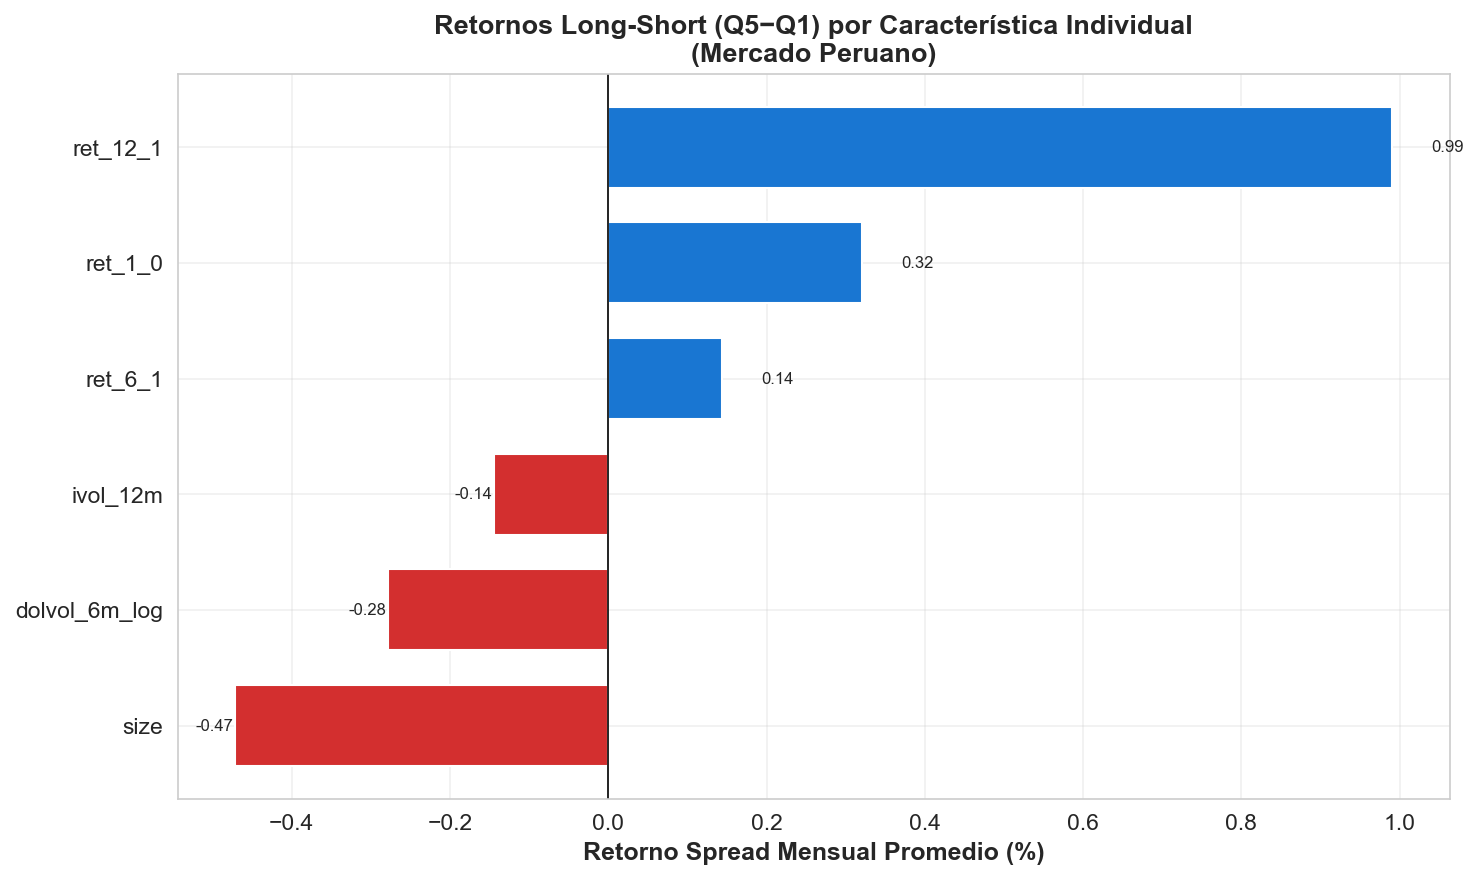

In [61]:
# =============================================================================
# Gráfico 1: Retornos Long-Short por característica individual
# =============================================================================
def compute_univariate_spreads(panel_df, char_cols, n_q=N_QUANTILES):
    """
    Para cada característica, forma quintiles y calcula el spread EW promedio.
    Sin modelo — solo sorting directo por la característica.
    """
    results = {}
    dates = sorted(panel_df['date'].unique())
    
    for c in char_cols:
        monthly_spreads = []
        for t in dates:
            cross = panel_df[panel_df['date'] == t].dropna(subset=[c, 'ret_forward']).copy()
            if len(cross) < n_q * 2:
                continue
            try:
                cross['q'] = pd.qcut(cross[c], n_q, labels=False, duplicates='drop') + 1
            except ValueError:
                continue
            top = cross[cross['q'] == n_q]['ret_forward'].mean()
            bot = cross[cross['q'] == 1]['ret_forward'].mean()
            if np.isfinite(top) and np.isfinite(bot):
                monthly_spreads.append(top - bot)
        
        if monthly_spreads:
            results[c] = {
                'mean': np.mean(monthly_spreads) * 100,
                't_stat': np.mean(monthly_spreads) / (np.std(monthly_spreads) / np.sqrt(len(monthly_spreads)))
                          if np.std(monthly_spreads) > 0 else 0,
            }
    return pd.DataFrame(results).T.sort_values('mean')

print("Calculando spreads univariados por característica...")
univ_spreads = compute_univariate_spreads(panel_clean, CHAR_COLS)

fig, ax = plt.subplots(figsize=(10, max(6, len(univ_spreads) * 0.5)))
colors = ['#d32f2f' if x < 0 else '#1976d2' for x in univ_spreads['mean']]
bars = ax.barh(univ_spreads.index, univ_spreads['mean'], color=colors, edgecolor='white', height=0.7)

# Añadir estrellas de significancia
for i, (idx, row) in enumerate(univ_spreads.iterrows()):
    star = '***' if abs(row['t_stat']) > 2.58 else ('**' if abs(row['t_stat']) > 1.96 else ('*' if abs(row['t_stat']) > 1.64 else ''))
    offset = 0.05 if row['mean'] >= 0 else -0.05
    ax.text(row['mean'] + offset, i, f"{row['mean']:.2f}{star}", va='center', fontsize=8)

ax.set_xlabel('Retorno Spread Mensual Promedio (%)', fontweight='bold')
ax.set_title('Retornos Long-Short (Q5−Q1) por Característica Individual\n(Mercado Peruano)',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('data/fig1_spreads_por_caracteristica.png', dpi=300, bbox_inches='tight')
plt.show()

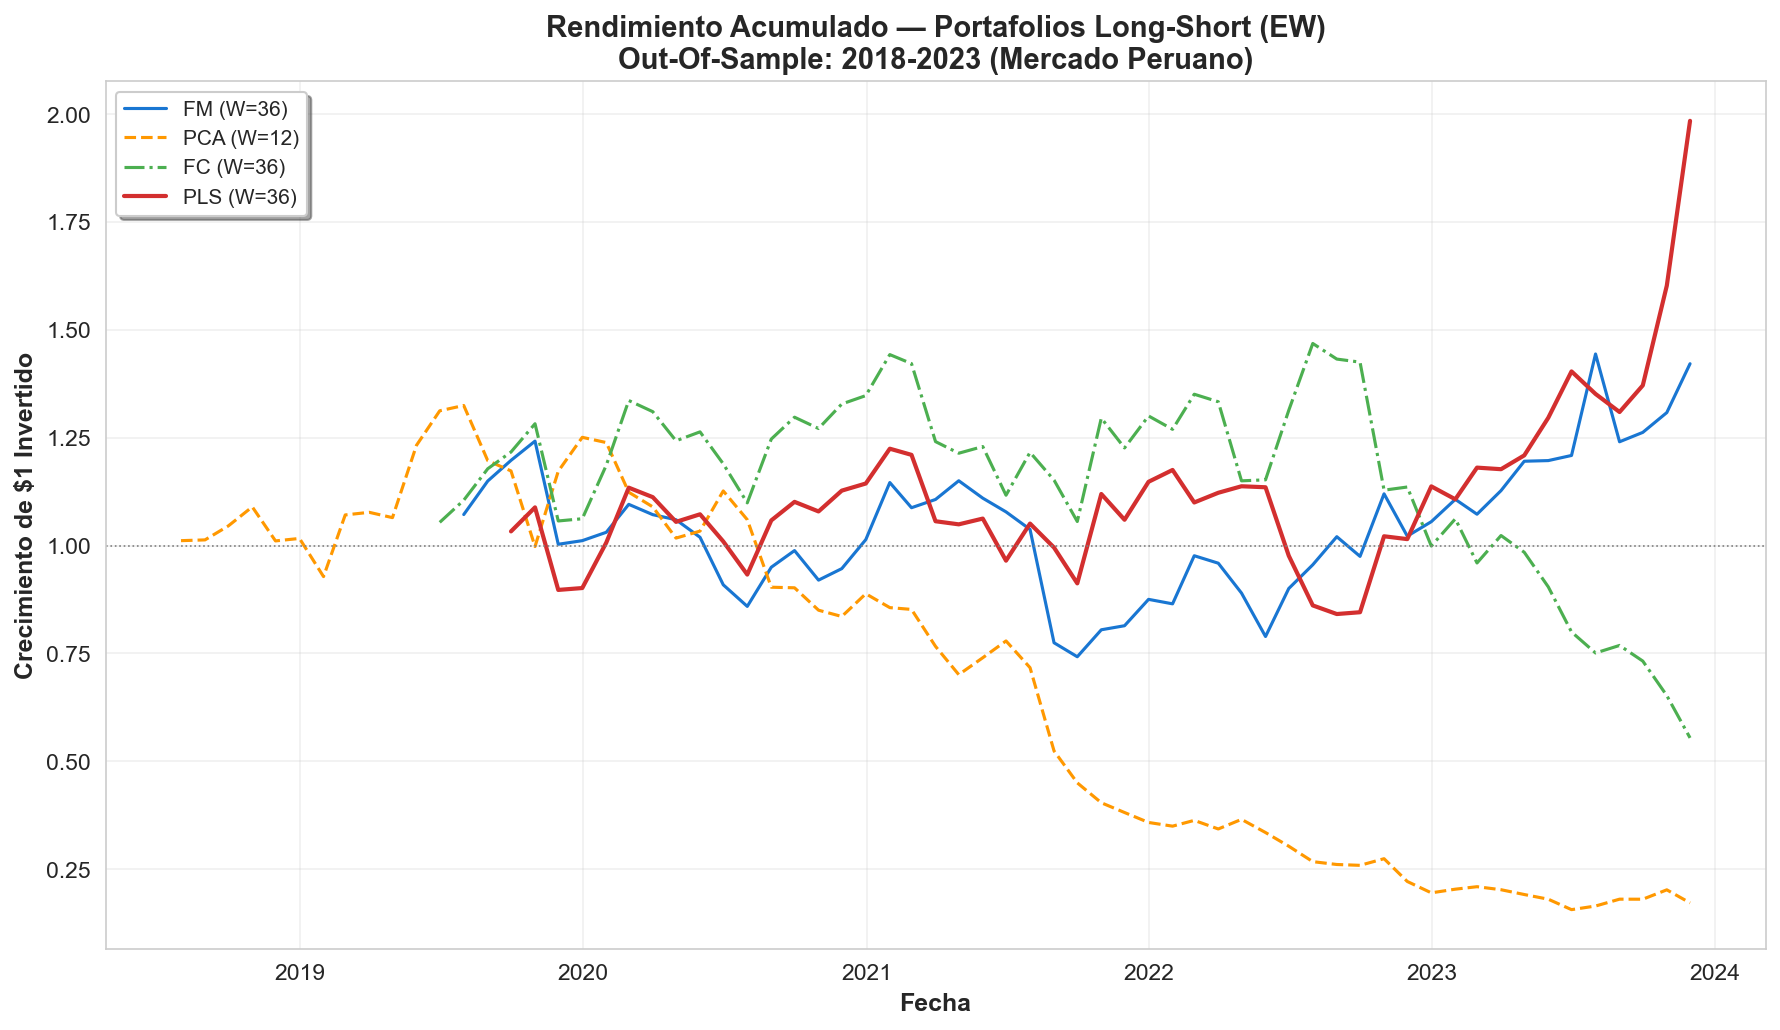

In [65]:
# =============================================================================
# 2: Retornos acumulados comparando FM, PCA, FC, PLS (OUT-OF-SAMPLE ONLY)
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 7))

model_colors = {'FM': '#1976d2', 'PCA': '#ff9800', 'FC': '#4caf50', 'PLS': '#d32f2f'}
model_styles = {'FM': '-', 'PCA': '--', 'FC': '-.', 'PLS': '-'}

for (model_name, w), port in all_portfolios.items():
    port_indexed = port.set_index('date').sort_index()
    spread = port_indexed['spread_EW'].dropna()
    cum_ret = (1 + spread).cumprod()
    
    ax.plot(cum_ret.index, cum_ret.values,
            label=f'{model_name} (W={w})',
            color=model_colors.get(model_name, 'gray'),
            linestyle=model_styles.get(model_name, '-'),
            linewidth=2.0 if model_name == 'PLS' else 1.5)

ax.set_title(f'Rendimiento Acumulado — Portafolios Long-Short (EW)\nOut-Of-Sample: 2018-2023 (Mercado Peruano)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontweight='bold')
ax.set_ylabel('Crecimiento de $1 Invertido', fontweight='bold')
ax.axhline(1, color='gray', linewidth=0.8, linestyle=':')
ax.legend(loc='upper left', frameon=True, shadow=True)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

plt.tight_layout()
plt.savefig('data/fig2_retornos_acumulados_OOS.png', dpi=300, bbox_inches='tight')
plt.show()

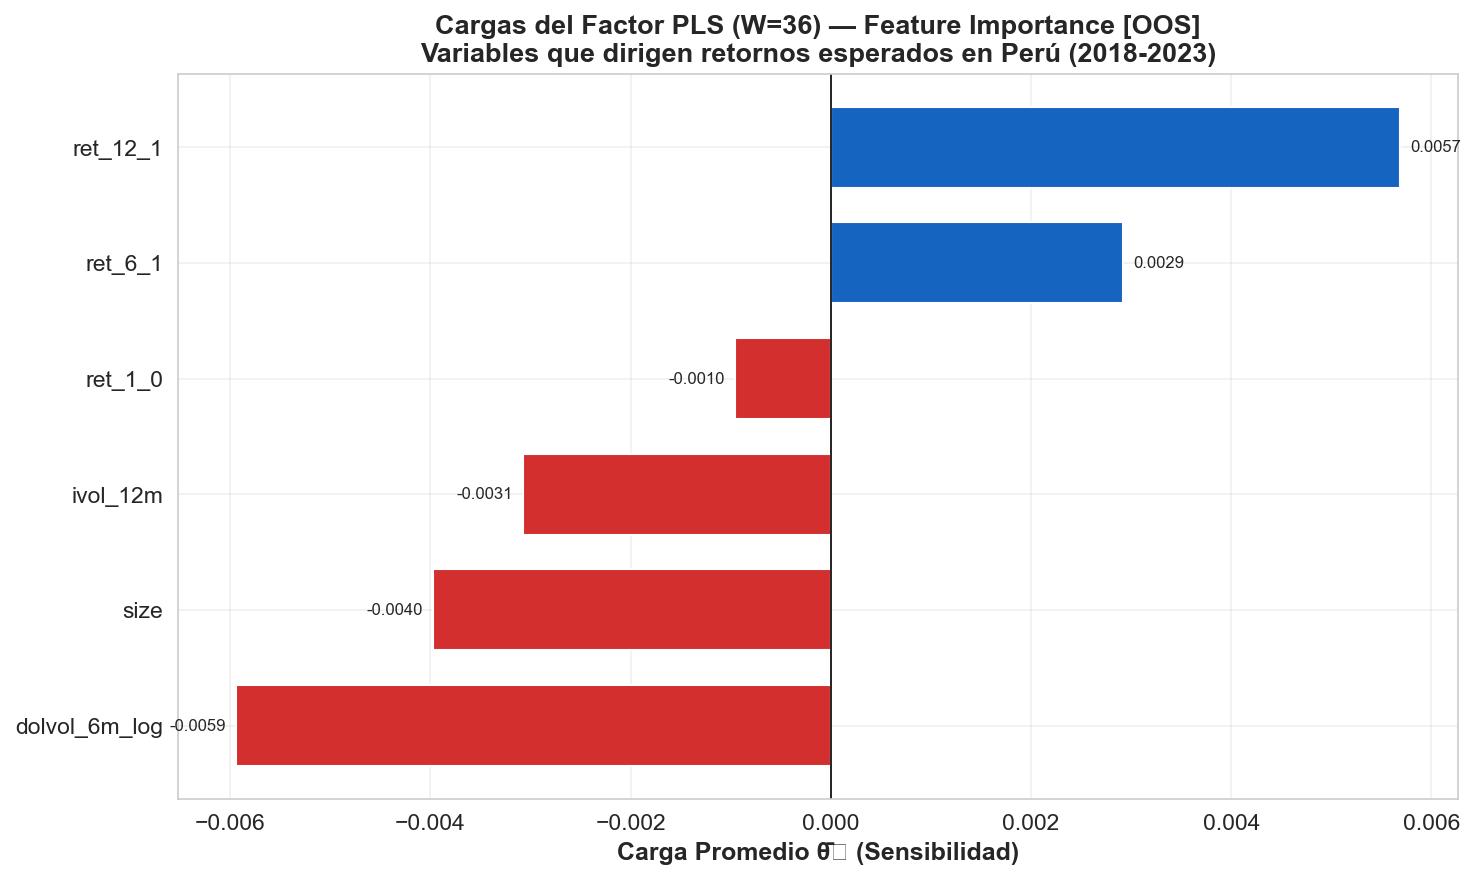

In [63]:
# =============================================================================
# Gráfico 3: Cargas PLS (Feature Importance) OUT-OF-SAMPLE
# =============================================================================
# Usar la ventana ganadora del PLS (la clave de mejor_w)
pls_key = [k for k in all_portfolios.keys() if k[0] == 'PLS']
if pls_key and pls_key[0][0] == 'PLS':
    pls_w = pls_key[0][1]
    if pls_w in pls_thetas:
        theta_df = pls_thetas[pls_w].dropna(how='all')
        avg_theta = theta_df.mean().sort_values()
        
        fig, ax = plt.subplots(figsize=(10, max(6, len(avg_theta) * 0.5)))
        colors = ['#d32f2f' if x < 0 else '#1565c0' for x in avg_theta.values]
        bars = ax.barh(avg_theta.index, avg_theta.values, color=colors, edgecolor='white', height=0.7)

        ax.set_xlabel('Carga Promedio θ̄ₖ (Sensibilidad)', fontweight='bold')
        ax.set_title(f'Cargas del Factor PLS (W={pls_w}) — Feature Importance [OOS]\n'
                    'Variables que dirigen retornos esperados en Perú (2018-2023)',
                    fontsize=13, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8)

        # Anotar valores
        for i, (name, val) in enumerate(avg_theta.items()):
            offset = 0.0001 if val >= 0 else -0.0001
            ax.text(val + offset, i, f'{val:.4f}', va='center', fontsize=8,
                    ha='left' if val >= 0 else 'right')

        plt.tight_layout()
        plt.savefig('data/fig3_pls_feature_importance_OOS.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Thetas no disponibles para PLS")
else:
    print("No hay resultados PLS para graficar")

In [64]:
# =============================================================================
# Tabla resumen detallada: Q1, Q5, Spread (OOS — mejor modelo)
# =============================================================================
def quintile_detail_table(port_df, factors_df, nw_lags=NW_LAGS, n_q=N_QUANTILES):
    """
    Tabla con métricas para Q1 (bottom), Q_N (top) y Spread, esquema EW.
    """
    port_indexed = port_df.set_index('date').sort_index()
    
    detail = {}
    for col_label, col_name in [('Q1', 'Q1_EW'), (f'Q{n_q}', f'Q{n_q}_EW'), ('Spread', 'spread_EW')]:
        s = port_indexed[col_name].dropna()
        if len(s) < 12:
            detail[col_label] = {k: np.nan for k in ['Mean (%)', 't-stat', 'SR',
                                                       'CAPM α', 't(α CAPM)',
                                                       'FF3 α', 't(α FF3)',
                                                       'FF5 α', 't(α FF5)']}
            continue
        
        m = evaluate_portfolio(s, factors_df, nw_lags)
        detail[col_label] = {
            'Mean (%)':    f"{m['mean_pct']:.2f}",
            't-stat':      f"{m['t_stat']:.2f}",
            'SR':          f"{m['SR']:.3f}",
            'CAPM α':      f"{m['capm_alpha']:.2f}" if np.isfinite(m['capm_alpha']) else 'n/a',
            't(α CAPM)':   f"{m['t_capm']:.2f}" if np.isfinite(m['t_capm']) else 'n/a',
            'FF3 α':       f"{m['ff3_alpha']:.2f}" if np.isfinite(m['ff3_alpha']) else 'n/a',
            't(α FF3)':    f"{m['t_ff3']:.2f}" if np.isfinite(m['t_ff3']) else 'n/a',
            'FF5 α':       f"{m['ff5_alpha']:.2f}" if np.isfinite(m['ff5_alpha']) else 'n/a',
            't(α FF5)':    f"{m['t_ff5']:.2f}" if np.isfinite(m['t_ff5']) else 'n/a',
        }
    
    return pd.DataFrame(detail)

# Mostrar para el mejor modelo OOS
if len(all_portfolios) > 0:
    best_key = list(all_portfolios.keys())[0]  # Primer modelo disponible
    print("=" * 80)
    print(f"DETALLE POR QUINTIL — {best_key[0]} (W={best_key[1]}), Equal-Weighted [OOS]")
    print("=" * 80)
    detail_table = quintile_detail_table(all_portfolios[best_key], factors_peru_oos)
    print(detail_table.to_string())
else:
    print("No hay resultados OOS para mostrar")

DETALLE POR QUINTIL — FM (W=36), Equal-Weighted [OOS]
              Q1     Q5 Spread
Mean (%)    0.31   1.34   1.02
t-stat      0.28   1.31   1.12
SR         0.135  0.597  0.423
CAPM α      0.34   1.42   1.08
t(α CAPM)   0.31   1.77   1.29
FF3 α       0.19   2.13   1.93
t(α FF3)    0.21   2.34   2.16
FF5 α       0.36   2.20   1.85
t(α FF5)    0.35   2.37   1.83
